<a href="https://colab.research.google.com/github/Pandabear-67/Collision-tracker/blob/main/LSTM_Autoencoder/LSTM_experiment_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#imports
import h5py
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/accident_files/"
import sys
sys.path.append(base_path)

In [ ]:
H5_PATH = "/content/drive/MyDrive/accident_files/lstm_data/features_interactions.h5"

with h5py.File(H5_PATH, "r") as f:
    X = f["X"][:]   # (N, 16, 50, 13)

print("Raw shape:", X.shape)

# flatten per timestep: 50 objects × 13 features = 650
N, T, O, F = X.shape
X = X.reshape(N, T, O * F)

print("Flattened shape:", X.shape)  # (N, 16, 650)

# optional: normalize (important for AE stability)
X = X.astype("float32")

# train/val split (no labels needed for AE training)
X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

Raw shape: (6009, 16, 50, 19)
Flattened shape: (6009, 16, 950)


In [ ]:
timesteps = X.shape[1]
features = X.shape[2]
latent_dim = 64

# -------- Encoder --------
inputs = layers.Input(shape=(timesteps, features))

encoded = layers.LSTM(128, return_sequences=True)(inputs)
encoded = layers.LSTM(64, return_sequences=False)(encoded)

latent = layers.RepeatVector(timesteps)(encoded)

# -------- Decoder --------
decoded = layers.LSTM(64, return_sequences=True)(latent)
decoded = layers.LSTM(128, return_sequences=True)(decoded)

outputs = layers.TimeDistributed(
    layers.Dense(features)
)(decoded)

model = Model(inputs, outputs)
model.compile(optimizer="adam", loss="mse")

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16, 950)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16, 128)        │       552,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 16, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 16, 950)        │       122,550 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 856,246 (3.27 MB)

 Trainable params: 856,246 (3.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 14130172.0000 - val_loss: 15330708.0000
Epoch 2/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 14129550.0000 - val_loss: 15330135.0000
Epoch 3/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 14128999.0000 - val_loss: 15329590.0000
Epoch 4/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 14128480.0000 - val_loss: 15329074.0000
Epoch 5/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 14127970.0000 - val_loss: 15328552.0000
Epoch 6/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 14127481.0000 - val_loss: 15328055.0000
Epoch 7/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 14127010.0000 - val_loss: 15327566.0000
Epoch 8/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 14126546.0000 - val_loss: 15327099.0000
Epoch 9/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 14126081.0000 - val_loss: 15326625.0000
Epoch 10/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 14125624.0000 - val_loss: 15

In [ ]:
model.save("/content/drive/MyDrive/accident_files/models/accident_interactions_autoencoder.keras")

In [ ]:
X_pred = model.predict(X_val)

# per-sample MSE over full sequence
recon_error = np.mean(np.square(X_val - X_pred), axis=(1,2))

# threshold: common robust choice
threshold = np.mean(recon_error) + 2*np.std(recon_error)

print("Threshold:", threshold)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
Threshold: 1.3958706


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def detect_accident(
    video_path,
    lstm_autoencoder,
    detector_tracker,
    optical_flow,
    device,
    fps=30,
    threshold=0.01,
    alpha=0.6
):
    extractor = VideoFrameExtractor(video_path)
    fps = extractor.fps if extractor.fps > 0 else fps

    feat_builder = FeatureBuilder()
    seq_builder = SequenceBuilder(seq_len=16, max_objects=50, feat_dim=13)

    lstm_autoencoder.eval()

    prev_frame = None

    frame_indices = []
    times = []
    anomaly_scores = []

    for frame_idx, frame in extractor.get_frames():

        # -----------------------------
        # 1. Detection + tracking
        # -----------------------------
        boxes, ids = detector_tracker.update(frame)

        if prev_frame is not None:

            # -----------------------------
            # 2. Optical flow
            # -----------------------------
            flow = optical_flow.compute_flow(prev_frame, frame)

            # -----------------------------
            # 3. Feature extraction
            # -----------------------------
            obj_feats = feat_builder.bbox_to_features(boxes, ids, frame.shape)
            flow_feats = pool_flow(flow, boxes)

            if len(obj_feats) == 0:
                full_feats = np.zeros((1, 13), dtype=np.float32)
            else:
                n = min(len(obj_feats), len(flow_feats))
                full_feats = np.concatenate(
                    [obj_feats[:n], flow_feats[:n]],
                    axis=1
                )

            # -----------------------------
            # 4. Build sequence
            # -----------------------------
            seq = seq_builder.add_frame(full_feats)

            # -----------------------------
            # 5. LSTM autoencoder inference
            # -----------------------------
            if seq is not None:
                seq_flat = seq.reshape(1, 16, 50 * 13)
                seq_tensor = torch.tensor(seq_flat, dtype=torch.float32).to(device)

                with torch.no_grad():
                    recon = lstm_autoencoder(seq_tensor)

                # reconstruction error (single score per window)
                error = torch.mean((seq_tensor - recon) ** 2).item()

                frame_indices.append(frame_idx)
                times.append(frame_idx / fps)
                anomaly_scores.append(error)

        prev_frame = frame

    # -----------------------------
    # 6. Detect first anomaly spike
    # -----------------------------
    anomaly_scores = np.array(anomaly_scores)

    # smoothing (important for stability)
    smooth_scores = np.copy(anomaly_scores)
    for i in range(1, len(smooth_scores)):
        smooth_scores[i] = alpha * smooth_scores[i] + (1 - alpha) * smooth_scores[i - 1]

    spike_idx = None
    for i, s in enumerate(smooth_scores):
        if s > threshold:
            spike_idx = i
            break

    if spike_idx is not None:
        accident_frame = frame_indices[spike_idx]
        accident_time = times[spike_idx]
        score = smooth_scores[spike_idx]

        print("ACCIDENT DETECTED")
        print("Frame:", accident_frame)
        print("Time (s):", accident_time)
        print("Score:", score)
    else:
        accident_frame, accident_time, score = -1, None, None
        print("No accident detected")

    # -----------------------------
    # 7. Visualization
    # -----------------------------
    plt.plot(times, smooth_scores)
    plt.axhline(threshold, color="g")
    if spike_idx is not None:
        plt.axvline(accident_time, color="r")
    plt.xlabel("Time (s)")
    plt.ylabel("Reconstruction error")
    plt.title("Accident Detection Signal")
    plt.show()

    return accident_frame, accident_time, score

In [ ]:
base_path = "/content/drive/MyDrive/accident_files/notebooks"
import sys
sys.path.append(base_path)

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.5 MB/s eta 0:00:00


In [ ]:
base_path = "/content/drive/MyDrive/accident_files/notebooks"
import sys
sys.path.append(base_path)

In [ ]:
import cv2

class VideoFrameExtractor:
    def __init__(self, video_path):
        self.video_path = video_path
        self.cap = cv2.VideoCapture(video_path)

        if not self.cap.isOpened():
            raise ValueError(f"Could not open video: {video_path}")

        # FPS (fallback-safe)
        self.fps = self.cap.get(cv2.CAP_PROP_FPS)
        if self.fps is None or self.fps <= 0:
            self.fps = 30.0

        # total frames (optional, may be 0 for some codecs)
        self.total_frames = int(self.cap.get(cv2.CAP_PROP_FRAME_COUNT))

    def get_frames(self):
        """
        Generator yielding:
            frame_idx (int), frame (BGR image as numpy array)
        """
        frame_idx = 0

        while True:
            ret, frame = self.cap.read()
            if not ret:
                break

            yield frame_idx, frame
            frame_idx += 1

        self.cap.release()

    def reset(self):
        """
        Rewinds video for re-use.
        """
        self.cap.release()
        self.cap = cv2.VideoCapture(self.video_path)

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tracking_flow_pipeline_experiment import DetectorTracker, OpticalFlow, FeatureBuilder, SequenceBuilder, HDF5Writer, pool_flow

def detect_accident(
    video_path,
    lstm_autoencoder,
    detector_tracker,
    optical_flow,
    device,
    fps=30,
    threshold=0.01,
    alpha=0.6
):

    extractor = VideoFrameExtractor(video_path)
    fps = extractor.fps if extractor.fps > 0 else fps

    feat_builder = FeatureBuilder()
    seq_builder = SequenceBuilder(seq_len=16, max_objects=50, feat_dim=13)

    prev_frame = None

    frame_indices = []
    times = []
    anomaly_scores = []

    for frame_idx, frame in extractor.get_frames():

        # -----------------------------
        # 1. Detection + tracking
        # -----------------------------
        boxes, ids = detector_tracker.update(frame)

        if prev_frame is not None:

            # -----------------------------
            # 2. Optical flow
            # -----------------------------
            flow = optical_flow.compute_flow(prev_frame, frame)

            # -----------------------------
            # 3. Feature extraction
            # -----------------------------
            obj_feats = feat_builder.bbox_to_features(boxes, ids, frame.shape)
            flow_feats = pool_flow(flow, boxes)

            if len(obj_feats) == 0:
                full_feats = np.zeros((1, 13), dtype=np.float32)
            else:
                n = min(len(obj_feats), len(flow_feats))
                full_feats = np.concatenate(
                    [obj_feats[:n], flow_feats[:n]],
                    axis=1
                )  # (n, 23)

            # -----------------------------
            # 4. Build sequence
            # -----------------------------
            seq = seq_builder.add_frame(full_feats)

            # -----------------------------
            # 5. LSTM autoencoder inference
            # -----------------------------
            if seq is not None:
                seq_flat = seq.reshape(1, 16, 50 * 13)

                recon = lstm_autoencoder.predict(seq_flat, verbose=0)
                error = np.mean((seq_flat - recon) ** 2)

                frame_indices.append(frame_idx)
                times.append(frame_idx / fps)
                anomaly_scores.append(error)

        prev_frame = frame

    # -----------------------------
    # 6. Peak anomaly detection
    # -----------------------------
    anomaly_scores = np.array(anomaly_scores)

    if len(anomaly_scores) == 0:
        print("No data processed")
        return -1, None, None

    # smoothing
    smooth_scores = np.copy(anomaly_scores)
    for i in range(1, len(smooth_scores)):
        smooth_scores[i] = alpha * smooth_scores[i] + (1 - alpha) * smooth_scores[i - 1]

    # peak detection
    peak_idx = np.argmax(smooth_scores)
    peak_score = smooth_scores[peak_idx]

    if peak_score > threshold:
        accident_frame = frame_indices[peak_idx]
        accident_time = times[peak_idx]
        score = peak_score

        print("ACCIDENT DETECTED (PEAK)")
        print("Frame:", accident_frame)
        print("Time (s):", accident_time)
        print("Score:", score)
    else:
        accident_frame, accident_time, score = -1, None, None
        print("No anomaly above threshold")

    # -----------------------------
    # 7. Visualization
    # -----------------------------
    plt.plot(times, smooth_scores)
    plt.axhline(threshold)
    if accident_time is not None:
        plt.axvline(accident_time)
    plt.xlabel("Time (s)")
    plt.ylabel("Reconstruction error")
    plt.title("Accident Detection Signal")
    plt.show()

    return accident_frame, accident_time, score

In [ ]:
lstm_autoencoder = tf.keras.models.load_model("/content/drive/MyDrive/accident_files/models/accident_autoencoder.keras")
detector = DetectorTracker("/content/drive/MyDrive/accident_files/models/yolo26n_apr5.pt")
flow = OpticalFlow("/content/drive/MyDrive/accident_files/RAFT/models/raft-sintel.pth")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ACCIDENT DETECTED (PEAK)
Frame: 24
Time (s): 1.6022222222222222
Score: 2.103841


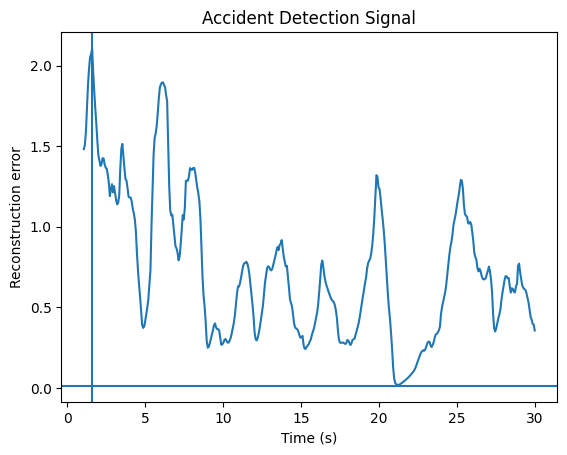

(24, 1.6022222222222222, np.float32(2.103841))

In [ ]:
detect_accident(video_path="/content/drive/MyDrive/accident_files/videos/5fSIVNb3L64_00.mp4",lstm_autoencoder=lstm_autoencoder, detector_tracker=detector, optical_flow=flow, device=device)